Creates Figure 12 of main paper

In [1]:
# load packages needed in this notebook
import copy
import os

import cartopy.crs as ccrs
import matplotlib as mpl
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import regionmask
import xarray as xr
from cartopy.util import add_cyclic_point
from eofs.standard import Eof
from matplotlib import pyplot as PP

ERROR 1: PROJ: proj_create_from_database: Open of /glade/u/home/nmaher/.conda/envs/clara/share/proj failed


In [2]:
# models=['CESM2-LE_FULL','CESM1-LE','ACCESS-SSP370','ACCESS-SSP585','CanESM5-SSP370','CanESM5-SSP585','CSIRO-Mk360','GFDL-SPEAR','IPSL-CM6A','MIROC6','MPI-GE']
models = [
    "CESM2",
    "CESM1-LE",
    "ACCESS-SSP370",
    "CanESM5-SSP370",
    "GFDL-SPEAR",
    "IPSL-CM6A",
    "MIROC6",
    "MPI-GE",
]
models_title = [
    "CESM2",
    "CESM1",
    "ACCESS",
    "CanESM5",
    "GFDL-SPEAR",
    "IPSL-CM6A",
    "MIROC6",
    "MPI-GE",
]

# tell me when the start year is
syear = [1850, 1920, 1850, 1850, 1921, 1850, 1850, 1850]

# load lon lat should be same for all models
outputdira = "/glade/campaign/cgd/cas/nmaher/cesm1_lens/Amon/zg/"
ds_fx = xr.open_dataset(
    outputdira + "zg_Amon_CESM1-CAM5_historical_rcp85_r10i1p1_192001-210012_g025.nc"
)

lon = ds_fx.lon
lat = ds_fx.lat

In [3]:
# load data
outputdir_figD = "/glade/work/nmaher/SEOF_output/Fig_data/"

In [4]:
cdataE_tot = np.zeros([8, 6, 72, 145])
cdataL_tot = np.zeros([8, 6, 72, 145])

In [5]:
# define 2d lat and lon points for ploting sig locs
lons = lon
lats = lat

In [6]:
lons[93:99]  # -115 to -125 235 245

<xarray.DataArray 'lon' (lon: 6)>
array([233.75, 236.25, 238.75, 241.25, 243.75, 246.25])
Coordinates:
  * lon      (lon) float64 233.8 236.2 238.8 241.2 243.8 246.2
Attributes:
    standard_name:  longitude
    long_name:      longitude
    units:          degrees_east
    axis:           X

In [7]:
lats[48:54]

<xarray.DataArray 'lat' (lat: 6)>
array([31.25, 33.75, 36.25, 38.75, 41.25, 43.75])
Coordinates:
  * lat      (lat) float64 31.25 33.75 36.25 38.75 41.25 43.75
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y

In [8]:
from matplotlib.gridspec import GridSpec

data_std = np.zeros([8, 8, 226]) * np.nan

c = ["b", "k", "r", "c", "tab:orange", "m", "tab:purple", "tab:olive"]


# fig,axs = PP.subplots(10,4,figsize=(35,20), subplot_kw={'projection': ccrs.Robinson(central_longitude=270)})
fig = plt.figure(figsize=(100, 100))
gs = GridSpec(4, 2, wspace=0.3)

ii = -1
for model in models:
    ii = ii + 1
    offset = 1921 - syear[ii]

    eof_T = "_F1bdata_zgNPac"
    with np.load(outputdir_figD + model + eof_T + ".npz") as npz:
        data_z500_npac = np.ma.MaskedArray(**npz) * 86400

    eof_T = "_F1bdata_zgNAt"
    with np.load(outputdir_figD + model + eof_T + ".npz") as npz:
        data_z500_nat = np.ma.MaskedArray(**npz) * 86400

    eof_T = "_F6data_pr"
    with np.load(outputdir_figD + model + eof_T + ".npz") as npz:
        data_z500 = np.ma.MaskedArray(**npz)

    if ii == 0:
        data_z500_npac = data_z500_npac * 1000
        data_z500_nat = data_z500_nat * 1000

    cali_nat = data_z500_nat[:, :, 48:54, 93:99].mean(axis=2)
    cali_nat = cali_nat.mean(axis=2)

    cali_npac = data_z500_npac[:, :, 48:54, 93:99].mean(axis=2)
    cali_npac = cali_npac.mean(axis=2)

    cali_tpac = data_z500[:, :, 48:54, 93:99].mean(axis=2)
    cali_tpac = cali_tpac.mean(axis=2)

    k = 20

    ax1 = plt.subplot(gs[0, 0])
    time = np.zeros(len(cali_nat[0, :]))
    cali_npac2 = np.zeros([3, len(cali_nat[0, :]) - k])
    cali_nat2 = np.zeros([1, len(cali_nat[0, :]) - k])
    cali_tpac2 = np.zeros([4, len(cali_tpac[0, :]) - k])

    for i in range(len(cali_nat[0, :])):
        time[i] = syear[ii] + i
    for i in range(len(cali_nat[0, :]) - k):
        cali_npac2[:, i] = cali_npac[:, i : i + k].mean(axis=1)
        cali_nat2[:, i] = cali_nat[:, i : i + k].mean(axis=1)

    for i in range(len(cali_tpac[0, :]) - k):
        cali_tpac2[:, i] = cali_tpac[:, i : i + k].mean(axis=1)
    offset = syear[ii] - 1850
    if ii < 7:
        data_std[ii, 0:3, 0 + offset :] = cali_npac2
        data_std[ii, 3, 0 + offset :] = cali_nat2
        data_std[ii, 4:8, 0 + offset : -1] = cali_tpac2

    else:
        data_std[ii, 0:3, 0 + offset : -1] = cali_npac2
        data_std[ii, 3, 0 + offset : -1] = cali_nat2
        data_std[ii, 4:8, 0 + offset : -2] = cali_tpac2

    time2 = time[10:-10]
    if ii == 0:
        (d11,) = ax1.plot(time2, cali_npac2[0, :], c[ii], linewidth=3)
    if ii == 1:
        (d12,) = ax1.plot(time2, cali_npac2[0, :], c[ii], linewidth=3)
    if ii == 2:
        (d13,) = ax1.plot(time2, cali_npac2[0, :], c[ii], linewidth=3)
    if ii == 3:
        (d14,) = ax1.plot(time2, cali_npac2[0, :], c[ii], linewidth=3)
    if ii == 4:
        (d15,) = ax1.plot(time2, cali_npac2[0, :], c[ii], linewidth=3)
    if ii == 5:
        (d16,) = ax1.plot(time2, cali_npac2[0, :], c[ii], linewidth=3)
    if ii == 6:
        (d17,) = ax1.plot(time2, cali_npac2[0, :], c[ii], linewidth=3)
    if ii == 7:
        (d18,) = ax1.plot(time2, cali_npac2[0, :], c[ii], linewidth=3)
    plt.yticks(fontsize=50)
    plt.xticks(fontsize=50)
    ax2 = plt.subplot(gs[1, 0])
    d2 = ax2.plot(time2, cali_npac2[1, :], c[ii], linewidth=3)
    plt.yticks(fontsize=50)
    plt.xticks(fontsize=50)
    ax3 = plt.subplot(gs[2, 0])
    d3 = ax3.plot(time2, cali_npac2[2, :], c[ii], linewidth=3)
    plt.yticks(fontsize=50)
    plt.xticks(fontsize=50)
    ax4 = plt.subplot(gs[3, 0])
    d4 = ax4.plot(time2, cali_nat2[0, :], c[ii], linewidth=3)
    plt.yticks(fontsize=50)
    plt.xticks(fontsize=50)

    time3 = time[10:-11]
    ax1b = plt.subplot(gs[0, 1])
    d1b = ax1b.plot(time3, cali_tpac2[0, :], c[ii], linewidth=3)
    plt.yticks(fontsize=50)
    plt.xticks(fontsize=50)
    ax2b = plt.subplot(gs[1, 1])
    d2b = ax2b.plot(time3, cali_tpac2[1, :], c[ii], linewidth=3)
    plt.yticks(fontsize=50)
    plt.xticks(fontsize=50)
    ax3b = plt.subplot(gs[2, 1])
    d3b = ax3b.plot(time3, cali_tpac2[2, :], c[ii], linewidth=3)
    plt.yticks(fontsize=50)
    plt.xticks(fontsize=50)
    ax4b = plt.subplot(gs[3, 1])
    d4b = ax4b.plot(time3, cali_tpac2[3, :], c[ii], linewidth=3)

    ax1.set_ylim(-0.8, 0.8)
    ax2.set_ylim(-0.8, 0.8)
    ax3.set_ylim(-0.8, 0.8)
    ax4.set_ylim(-0.8, 0.8)

    ax1.set_xlim(1850, 2100)
    ax2.set_xlim(1850, 2100)
    ax3.set_xlim(1850, 2100)
    ax4.set_xlim(1850, 2100)

    ax1b.set_ylim(-0.8, 0.8)
    ax2b.set_ylim(-0.8, 0.8)
    ax3b.set_ylim(-0.8, 0.8)
    ax4b.set_ylim(-0.8, 0.8)

    ax1b.set_xlim(1850, 2100)
    ax2b.set_xlim(1850, 2100)
    ax3b.set_xlim(1850, 2100)
    ax4b.set_xlim(1850, 2100)

    ax1.set_ylabel("precip (mm)", fontsize=50)
    ax2.set_ylabel("precip (mm)", fontsize=50)
    ax3.set_ylabel("precip (mm)", fontsize=50)
    ax4.set_ylabel("precip (mm)", fontsize=50)

    ax1b.set_ylabel("precip (mm)", fontsize=50)
    ax2b.set_ylabel("precip (mm)", fontsize=50)
    ax3b.set_ylabel("precip (mm)", fontsize=50)
    ax4b.set_ylabel("precip (mm)", fontsize=50)

    plt.yticks(fontsize=50)
    plt.xticks(fontsize=50)

    ax1.set_title("NPac Z$_{500}$ SEOF1", fontsize=75, weight="bold")
    ax2.set_title("NPac Z$_{500}$ SEOF2", fontsize=75, weight="bold")
    ax3.set_title("NPac Z$_{500}$ SEOF3", fontsize=75, weight="bold")
    ax4.set_title("NAtl Z$_{500}$ SEOF1", fontsize=75, weight="bold")

    ax1b.set_title("NPac Z$_{500}$ SEOF1 - TPAC", fontsize=75, weight="bold")
    ax2b.set_title("NPac Z$_{500}$ SEOF2 - TPAC", fontsize=75, weight="bold")
    ax3b.set_title("NPac Z$_{500}$ SEOF3 - TPAC", fontsize=75, weight="bold")
    ax4b.set_title("NAtl Z$_{500}$ SEOF1 - TPAC", fontsize=75, weight="bold")





ax1.legend(
    [d11, d12, d13, d14, d15, d16, d17, d18],
    [
        "CESM2",
        "CESM1",
        "ACCESS",
        "CanESM5",
        "GFDL-SPEAR",
        "IPSL-CM6A",
        "MIROC6",
        "MPI-GE",
    ],
    loc="upper left",
    fontsize=40,
)

outputdir2 = "/glade/work/nmaher/SEOF_output/figs_final/april25/"

plt.savefig(outputdir2 + "Figure_Supplementary_Cali_v2.png")
plt.show()

/glade/u/home/nmaher/.conda/envs/clara/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


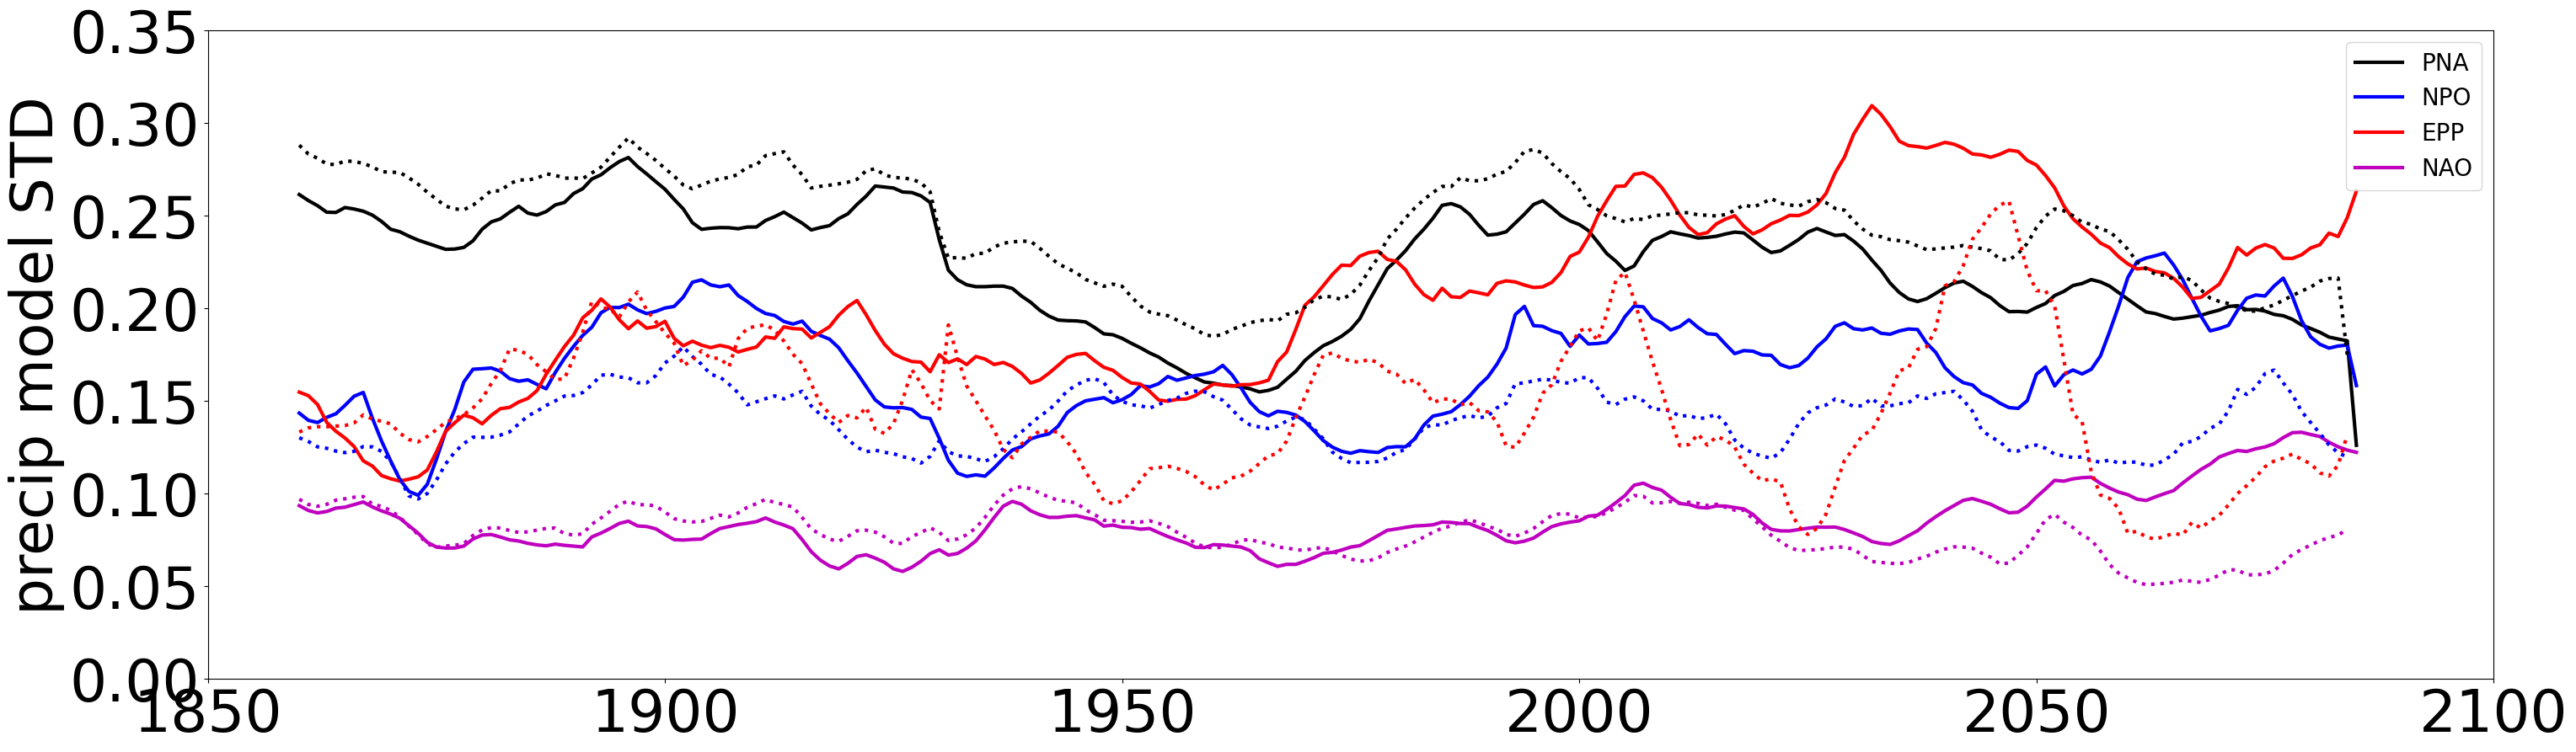

In [9]:
fig = plt.figure(figsize=(35, 10))
gs = GridSpec(1, 1, wspace=0.3)

time3 = time[10:-9]
ax1b = plt.subplot(gs[0, 0])
(d1b,) = ax1b.plot(time3, np.nanstd(data_std[:, 0, :], axis=0), "k", linewidth=3)
(d1c,) = ax1b.plot(time3, np.nanstd(data_std[:, 1, :], axis=0), "b", linewidth=3)
(d1d,) = ax1b.plot(time3, np.nanstd(data_std[:, 2, :], axis=0), "r", linewidth=3)
(d1e,) = ax1b.plot(time3, np.nanstd(data_std[:, 3, :], axis=0), "m", linewidth=3)

d1 = ax1b.plot(time3, np.nanstd(data_std[:, 4, :], axis=0), "k:", linewidth=3)
d1 = ax1b.plot(time3, np.nanstd(data_std[:, 5, :], axis=0), "b:", linewidth=3)
db = ax1b.plot(time3, np.nanstd(data_std[:, 6, :], axis=0), "r:", linewidth=3)
d1 = ax1b.plot(time3, np.nanstd(data_std[:, 7, :], axis=0), "m:", linewidth=3)

ax1b.legend(
    [d1b, d1c, d1d, d1e],
    [   "PNA",
        "NPO",
        "EPP",
        "NAO"  ],
    loc="upper right",
    fontsize=20,
)

ax1b.set_ylim(0, 0.35)
ax1b.set_xlim(1850, 2100)
ax1b.set_ylabel("precip model STD", fontsize=50)
plt.yticks(fontsize=50)
plt.xticks(fontsize=50)

outputdir2 = "/glade/work/nmaher/SEOF_output/figs_final/april25/"

plt.savefig(outputdir2 + "Figure_Supplementary_Cali_summary.png")
plt.show()

In [10]:
cali_nat2.shape

(1, 225)

In [11]:
cali_npac2.shape

(3, 225)

In [12]:
cali_tpac2.shape

(4, 224)

In [13]:
#ok so we need to load each model - do the difference then take the mean of the diff and save each infividually

#so want 2 plots 1 Cali and one EUs with plots just like the first one for rms = this is doable!

In [14]:
data_late=np.mean(data_std[:,:,214:224],axis=2)
data_early=np.nanmean(data_std[:,:,71:81],axis=2)
diff=data_late-data_early
mean_diff=np.mean(diff,axis=0)

In [15]:
rms2a=diff.reshape(8,2,4)

In [16]:
rmsa = mean_diff.reshape(2, 4)


In [17]:
rms = rmsa.swapaxes(0, 1)
rms2 = rms2a.swapaxes(1, 2)


In [18]:
data_std = np.zeros([8, 8, 226]) * np.nan


ii = -1
for model in models:
    ii = ii + 1
    offset = 1921 - syear[ii]

    eof_T = "_F1bdata_zgNPac"
    with np.load(outputdir_figD + model + eof_T + ".npz") as npz:
        data_z500_npac = np.ma.MaskedArray(**npz) * 86400

    eof_T = "_F1bdata_zgNAt"
    with np.load(outputdir_figD + model + eof_T + ".npz") as npz:
        data_z500_nat = np.ma.MaskedArray(**npz) * 86400

    eof_T = "_F6data_pr"
    with np.load(outputdir_figD + model + eof_T + ".npz") as npz:
        data_z500 = np.ma.MaskedArray(**npz)

    if ii == 0:
        data_z500_npac = data_z500_npac * 1000
        data_z500_nat = data_z500_nat * 1000

    cali_nat = data_z500_nat[:, :, 45:51, 108:115].mean(axis=2)
    cali_nat = cali_nat.mean(axis=2)

    cali_npac = data_z500_npac[:, :, 45:51, 108:115].mean(axis=2)
    cali_npac = cali_npac.mean(axis=2)

    cali_tpac = data_z500[:, :, 45:51, 108:115].mean(axis=2)
    cali_tpac = cali_tpac.mean(axis=2)

    k = 20

    time = np.zeros(len(cali_nat[0, :]))
    cali_npac2 = np.zeros([3, len(cali_nat[0, :]) - k])
    cali_nat2 = np.zeros([1, len(cali_nat[0, :]) - k])
    cali_tpac2 = np.zeros([4, len(cali_tpac[0, :]) - k])

    for i in range(len(cali_nat[0, :])):
        time[i] = syear[ii] + i
    for i in range(len(cali_nat[0, :]) - k):
        cali_npac2[:, i] = cali_npac[:, i : i + k].mean(axis=1)
        cali_nat2[:, i] = cali_nat[:, i : i + k].mean(axis=1)

    for i in range(len(cali_tpac[0, :]) - k):
        cali_tpac2[:, i] = cali_tpac[:, i : i + k].mean(axis=1)
    offset = syear[ii] - 1850
    if ii < 7:
        data_std[ii, 0:3, 0 + offset :] = cali_npac2
        data_std[ii, 3, 0 + offset :] = cali_nat2
        data_std[ii, 4:8, 0 + offset : -1] = cali_tpac2

    else:
        data_std[ii, 0:3, 0 + offset : -1] = cali_npac2
        data_std[ii, 3, 0 + offset : -1] = cali_nat2
        data_std[ii, 4:8, 0 + offset : -2] = cali_tpac2

In [19]:
data_late=np.mean(data_std[:,:,214:224],axis=2)
data_early=np.nanmean(data_std[:,:,71:81],axis=2)
diff=data_late-data_early
mean_diff=np.mean(diff,axis=0)

rms2ab=diff.reshape(8,2,4)
rmsab = mean_diff.reshape(2, 4)
rmsb = rmsab.swapaxes(0, 1)
rms2b = rms2ab.swapaxes(1, 2)

/glade/derecho/scratch/nmaher/tmp/ipykernel_70846/3921685192.py:20: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax = plt.subplot(gs[0, 0])
/glade/derecho/scratch/nmaher/tmp/ipykernel_70846/3921685192.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


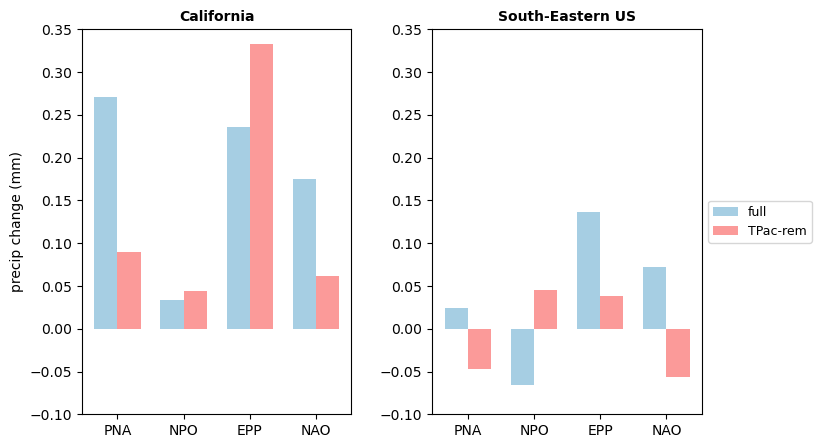

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Labels and colors
group_labels = ['PNA','NPO','EPP','NAO']
bar_labels = ['full', 'TPac-rem']
bar_colors = ['#a6cee3', '#fb9a99']  # pale blue and pale pink
markers = ['o','s','^','D','v','<','>','x']  # 8 markers
models_title = ['CESM2','CESM1','ACCESS','CanESM5','GFDL-SPEAR','IPSL-CM6A','MIROC6','MPI-GE']

n_groups = rms.shape[0]
n_bars = rms.shape[1]
x = np.arange(n_groups)
width = 0.35  # width of each bar

fig, ax = plt.subplots(figsize=(8,5))
gs = GridSpec(1, 2, wspace=0.3)

ax = plt.subplot(gs[0, 0])

# Plot bars
for i in range(n_bars):
    ax.bar(x + i*width - width/2, rms[:,i], width, color=bar_colors[i], label=bar_labels[i])

# Overlay symbols from rms2
#for g in range(n_groups):
#    for b in range(n_bars):
#        for m in range(rms2.shape[0]):  # 8 models
#            ax.plot(x[g] + b*width - width/2, rms2[m,g,b],
 #                   marker=markers[m], color='k', linestyle='None', alpha=0.8,
#                    label=models_title[m] if g==0 and b==0 else "")  # only add label once for legend

# Labels and legend
ax.set_xticks(x)
ax.set_xticklabels(group_labels)
ax.set_ylabel('precip change (mm)')
ax.set_ylim(-0.1, 0.35)

# Create a legend with bars and models
handles, labels = ax.get_legend_handles_labels()
# Remove duplicates from models
from collections import OrderedDict
by_label = OrderedDict(zip(labels, handles))

# Move legend to the right outside the plot
ax.legend(by_label.values(), by_label.keys(),
          loc='center left', bbox_to_anchor=(2.3, 0.5), fontsize=9)

ax.set_title("California", fontsize=10, weight="bold")

ax = plt.subplot(gs[0, 1])
#ax.ylim[(-0.1, 0.35)]
ax.set_ylim(-0.1, 0.35)
# Labels and colors
group_labels = ['PNA','NPO','EPP','NAO']
bar_labels = ['full', 'TPac-rem']
bar_colors = ['#a6cee3', '#fb9a99']  # pale blue and pale pink
#markers = ['o','s','^','D','v','<','>','x']  # 8 markers
#models_title = ['CESM2','CESM1','ACCESS','CanESM5','GFDL-SPEAR','IPSL-CM6A','MIROC6','MPI-GE']

n_groups = rms.shape[0]
n_bars = rms.shape[1]
x = np.arange(n_groups)
width = 0.35  # width of each bar


# Plot bars
for i in range(n_bars):
    ax.bar(x + i*width - width/2, rmsb[:,i], width, color=bar_colors[i], label=bar_labels[i])

# Overlay symbols from rms2
#for g in range(n_groups):
#    for b in range(n_bars):
 #       for m in range(rms2.shape[0]):  # 8 models
 #           ax.plot(x[g] + b*width - width/2, rms2b[m,g,b],
 #                   marker=markers[m], color='k', linestyle='None', alpha=0.8,label=models_title[m] if g==0 and b==0 else "")  # only add label once for legend

# Labels and legend
ax.set_xticks(x)
ax.set_xticklabels(group_labels)
#ax.set_ylabel('RMS S/N')

# Create a legend with bars and models
handles, labels = ax.get_legend_handles_labels()
# Remove duplicates from models
from collections import OrderedDict
by_label = OrderedDict(zip(labels, handles))

ax.set_title("South-Eastern US", fontsize=10, weight="bold")

plt.tight_layout()


outputdir2='/glade/work/nmaher/SEOF_output/figs_final/revision/'
PP.savefig(outputdir2+'Figure12.png', dpi=300, bbox_inches='tight')
PP.show()